# Notebook 4

The Poincare disk model represents the hyperbolic plane $H^2$ as the open unit disk
$D = \{(x,y) : x^2+y^2 < 1\}$, equipped with the conformal metric

$$
ds^2 = \lambda(x,y)^2 (dx^2+dy^2), \qquad \lambda(x,y) = \frac{2}{1-x^2-y^2}
$$

Unlike the Sphere and Torus, $H^2$ has no isometric embedding into $\mathbb{R}^3$ (Hilbert's
theorem), so points here are genuine 2D vectors, and the "projection method" used for the
other two surfaces does not apply directly. Every formula used below (the tangent-noise
scaling, the boundary safety clamp, and the radial process $\rho_t = 2\,\mathrm{artanh}(|X_t|)$)
is derived step by step in `docs/writeups/2-poincare-disk-derivation.md`, starting from this
project's own stated convention that Brownian motion's generator is half the Laplace-Beltrami
operator. This notebook validates that implementation against closed-form targets from that
derivation, not against an empirical curve fit.

In [1]:
# Imports
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import kstest

import sys
sys.path.append("..")
from src.manifolds.hyperbolic import PoincareDisk
from src.simulation.simulator import hyperbolic_simulator

## Structural checks

Before any statistics, we check the basic structural properties that must hold by
construction:

- `project_to_tangent(x, v)` must return `v` unchanged, since $H^2$ is intrinsically
  2-dimensional (every tangent space is all of $\mathbb{R}^2$ -- see
  `docs/writeups/2-poincare-disk-derivation.md` section 5 in `hyperbolic.py`'s docstring).
- `project_to_manifold` must be idempotent, and must leave points already well inside the
  disk unchanged.
- `project_to_manifold` must clamp a point placed outside (or on) the unit circle back to
  radius $1-\varepsilon$, preserving its angle exactly (it is a radial rescale, not an
  arbitrary correction).

In [2]:
disk = PoincareDisk()
rng = np.random.default_rng(0)

def random_interior_point(rng, max_radius=0.9):
    """Samples a point genuinely inside the disk via polar coordinates
    (sampling x, y independently and uniformly can land outside the unit
    disk, e.g. (0.9, 0.9) has norm ~1.27 > 1)."""
    radius = rng.uniform(0.0, max_radius)
    angle = rng.uniform(0.0, 2 * np.pi)
    return radius * np.array([np.cos(angle), np.sin(angle)])

# project_to_tangent is the identity
for _ in range(20):
    x = random_interior_point(rng)
    v = rng.normal(size=2)
    assert np.array_equal(disk.project_to_tangent(x, v), v)

# project_to_manifold leaves interior points unchanged
for _ in range(20):
    x = random_interior_point(rng)
    assert np.allclose(disk.project_to_manifold(x), x)

# project_to_manifold is idempotent
for _ in range(20):
    x = random_interior_point(rng, max_radius=0.999)
    once = disk.project_to_manifold(x)
    twice = disk.project_to_manifold(once)
    assert np.allclose(once, twice)

# project_to_manifold clamps a point beyond the boundary to radius 1 - epsilon,
# preserving its angle
for _ in range(20):
    angle = rng.uniform(0, 2 * np.pi)
    over_radius = rng.uniform(1.0, 5.0)
    x = over_radius * np.array([np.cos(angle), np.sin(angle)])
    clamped = disk.project_to_manifold(x)
    assert np.isclose(np.linalg.norm(clamped), 1.0 - disk.epsilon)
    assert np.isclose(np.arctan2(clamped[1], clamped[0]), np.arctan2(x[1], x[0]))

print("All structural checks passed.")

All structural checks passed.


## Domain constraint and the clamp-trigger rate

The true continuous-time process never reaches the boundary $|x|=1$ in finite time (it is
transient to infinite geodesic distance, not to a finite-time boundary hit -- see
`docs/writeups/2-poincare-disk-derivation.md` section 6). The clamp in `project_to_manifold`
exists only to protect against floating-point overshoot in the discrete Euler-Maruyama
scheme. We run a long single-particle simulation and check two things: every point stays
strictly inside the disk, and the clamp fires rarely, at a rate that shrinks as `dt` shrinks
(evidence it is a negligible numerical safeguard, not a load-bearing part of the dynamics).

In [3]:
def run_single_path(T, dt, epsilon=1e-10):
    """Runs one particle's path by hand (rather than via euler_maruyama_step)
    so we can check every point stays inside the disk."""
    local_disk = PoincareDisk(epsilon=epsilon)
    x = np.array([0.0, 0.0])
    path = [x.copy()]
    for _ in range(T):
        noise = local_disk.sample_tangent_noise(x)
        x = local_disk.project_to_manifold(x + np.sqrt(dt) * noise)
        path.append(x.copy())
    return np.array(path)

T_long = 100_000
path = run_single_path(T_long, dt=0.01)
radii = np.linalg.norm(path, axis=1)
assert np.all(radii < 1.0)
print(f"Domain constraint held for all {T_long} steps. Max radius reached: {radii.max():.10f}")

def clamp_trigger_rate(N, total_time, dt, epsilon=1e-10):
    """Runs an ensemble of N particles for total_time/dt steps and returns the
    fraction of individual particle-steps whose proposed step would have landed
    at or beyond 1 - epsilon before the clamp corrects it. A single path's
    trigger count is dominated by chance (whether that one path happened to
    wander close to the boundary); pooling across many particles gives a
    stable rate estimate."""
    local_disk = PoincareDisk(epsilon=epsilon)
    T = int(total_time / dt)
    points = np.tile(np.array([0.0, 0.0]), (N, 1))
    triggers = 0
    for _ in range(T):
        noise = local_disk.sample_tangent_noise_multiple(points)
        proposed = points + np.sqrt(dt) * noise
        triggers += int(np.sum(np.linalg.norm(proposed, axis=1) >= 1.0 - epsilon))
        points = local_disk.project_to_manifold_multiple(proposed)
    return triggers / (N * T)

print()
print("Clamp-trigger rate as dt shrinks (ensemble of 1000 particles, total elapsed time t = 50):")
for dt_i in [0.05, 0.01, 0.005, 0.001]:
    rate = clamp_trigger_rate(N=1000, total_time=50, dt=dt_i)
    print(f"  dt={dt_i:<7} rate={rate:.3e}")

Domain constraint held for all 100000 steps. Max radius reached: 0.9999999999

Clamp-trigger rate as dt shrinks (ensemble of 1000 particles, total elapsed time t = 50):
  dt=0.05    rate=3.242e-02


  dt=0.01    rate=1.325e-02


  dt=0.005   rate=9.545e-03


  dt=0.001   rate=4.334e-03


## Trajectory visualization

A single long path, plotted in the disk together with the unit circle boundary. Consistent
with transience, the path should drift outward over time rather than returning repeatedly
near the origin the way Sphere/Torus paths do.

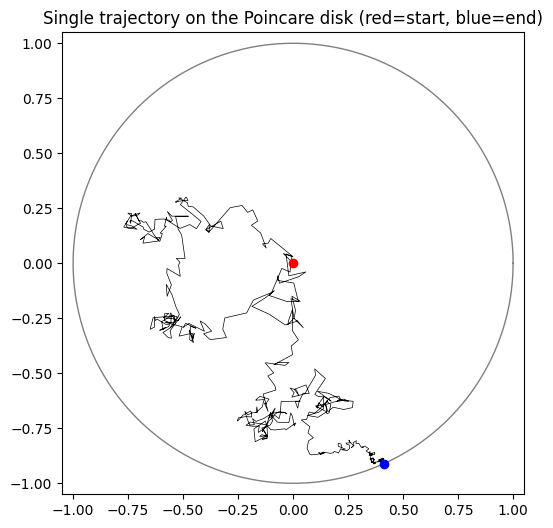

In [4]:
theta_circle = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(theta_circle), np.sin(theta_circle), color="gray", linewidth=1)
ax.plot(path[:, 0], path[:, 1], color="black", linewidth=0.5)
ax.plot(path[0, 0], path[0, 1], "o", color="red", markersize=6)
ax.plot(path[-1, 0], path[-1, 1], "o", color="blue", markersize=6)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.set_title("Single trajectory on the Poincare disk (red=start, blue=end)")
plt.show()

## Radial SDE coefficient recovery (primary validation)

`docs/writeups/2-poincare-disk-derivation.md` derives, from this project's own generator
convention, that the radial process $\rho_t = 2\,\mathrm{artanh}(|X_t|)$ satisfies

$$
d\rho_t = d\beta_t + \tfrac{1}{2}\coth(\rho_t)\,dt
$$

i.e. unit diffusion coefficient and drift $\tfrac12\coth(\rho)$. We simulate many independent
particles, and at every step bin the current $\rho$ and accumulate the sufficient statistics
(count, sum, sum of squares) of the increment $\Delta\rho$ per bin -- an online accumulation,
not a stored full trajectory, so this scales to a fine `dt` without a memory blowup. Afterward
we compare the empirical local drift $E[\Delta\rho\mid\rho]/dt$ and diffusion
$\mathrm{Var}[\Delta\rho\mid\rho]/dt$ against the closed-form targets.

**Why a much smaller `dt` here than elsewhere in this notebook:** an early version of this
check at `dt=0.01` (the value used throughout the rest of the notebook) recovered the drift
correctly, but the diffusion coefficient came out consistently ~2-3% high -- too large to be
sampling noise given the enormous sample sizes involved. Halving `dt` repeatedly (0.01 → 0.005
→ 0.002 → 0.001) shrank that bias roughly in proportion each time (2.36% → 1.19% → 0.54% →
0.21%), which is exactly the signature of Euler-Maruyama's known weak-order-1 discretization
bias (`docs/writeups/1-curriculum-checklist.md` §"Euler-Maruyama Convergence": *"weak
order 1"*, i.e. an $O(dt)$ error in expectations of smooth functionals) acting on the
nonlinear transform $\rho(x)$ of a discretely-simulated path -- not a derivation error. That
the bias shrinks linearly with `dt`, exactly as the convergence theorem predicts, is itself an
independent consistency check. We use `dt=0.0005` below so this bias is small relative to the
tolerance.

We also exclude the bin nearest $\rho=0$: $\coth(\rho)$ diverges there, so a bin of finite
width poorly approximates the theory curve by its center value -- a bin-resolution artifact,
not a breakdown of the theory (the small-$\rho$ limit is checked separately, and exactly, in
`docs/writeups/2-poincare-disk-derivation.md` section 5b via the Bessel(2) matching).

In [5]:
def radial_coefficient_recovery(N, T, dt, bin_edges):
    """Simulates N particles for T steps of size dt, and for each step bins
    the *current* rho value and accumulates count / sum / sum-of-squares of
    the increment delta_rho within that bin. Returns those accumulators, not
    a stored trajectory, so dt can be made small without a memory blowup."""
    local_disk = PoincareDisk()
    n_bins = len(bin_edges) - 1
    points = np.tile(np.array([0.0, 0.0]), (N, 1))
    rho = local_disk.geodesic_distance_from_origin_multiple(points)
    counts = np.zeros(n_bins)
    sums = np.zeros(n_bins)
    sumsqs = np.zeros(n_bins)
    for _ in range(T):
        noise = local_disk.sample_tangent_noise_multiple(points)
        points_new = points + np.sqrt(dt) * noise
        points_new = local_disk.project_to_manifold_multiple(points_new)
        rho_new = local_disk.geodesic_distance_from_origin_multiple(points_new)
        delta_rho = rho_new - rho
        bin_idx = np.digitize(rho, bin_edges) - 1
        valid = (bin_idx >= 0) & (bin_idx < n_bins)
        np.add.at(counts, bin_idx[valid], 1)
        np.add.at(sums, bin_idx[valid], delta_rho[valid])
        np.add.at(sumsqs, bin_idx[valid], delta_rho[valid] ** 2)
        points, rho = points_new, rho_new
    return counts, sums, sumsqs

dt_fine = 0.0005
bin_edges = np.linspace(1.0, 18.0, 18)  # excludes [0, 1) -- see markdown above
counts, sums, sumsqs = radial_coefficient_recovery(N=4000, T=40_000, dt=dt_fine, bin_edges=bin_edges)

print(f"{'rho range':<16}{'n':<10}{'drift (emp)':<14}{'drift (theory)':<16}{'within k*SE':<13}"
      f"{'diffusion (emp)':<18}{'within k*SE'}")

k = 6  # generous multiple of standard error, analogous to Notebook-01's 2*SE tolerance
all_ok = True
recovered_rho_centers, recovered_drifts, recovered_theory_drifts = [], [], []
for b in range(len(bin_edges) - 1):
    n = counts[b]
    if n < 500:
        continue
    mean_delta_rho = sums[b] / n
    var_delta_rho = (sumsqs[b] - n * mean_delta_rho**2) / (n - 1)
    rho_center = 0.5 * (bin_edges[b] + bin_edges[b + 1])

    empirical_drift = mean_delta_rho / dt_fine
    theory_drift = 0.5 / np.tanh(rho_center)
    drift_se = np.sqrt(var_delta_rho / n) / dt_fine
    drift_ok = abs(empirical_drift - theory_drift) < k * drift_se

    empirical_diffusion = var_delta_rho / dt_fine
    diffusion_se = empirical_diffusion * np.sqrt(2.0 / (n - 1))
    diffusion_ok = abs(empirical_diffusion - 1.0) < k * diffusion_se

    all_ok &= bool(drift_ok) and bool(diffusion_ok)
    recovered_rho_centers.append(rho_center)
    recovered_drifts.append(empirical_drift)
    recovered_theory_drifts.append(theory_drift)

    print(f"[{bin_edges[b]:.2f},{bin_edges[b+1]:.2f}) n={n:<9.0f}"
          f"{empirical_drift:<14.4f}{theory_drift:<16.4f}{str(drift_ok):<13}"
          f"{empirical_diffusion:<18.4f}{diffusion_ok}")

assert all_ok, "Empirical radial drift/diffusion deviates from the derived SDE beyond tolerance"
print()
print("All binned drift and diffusion coefficients matched the derived radial SDE within tolerance.")

rho range       n         drift (emp)   drift (theory)  within k*SE  diffusion (emp)   within k*SE
[1.00,2.00) n=15062017 0.5698        0.5524          True         1.0009            True
[2.00,3.00) n=15482897 0.4956        0.5068          True         1.0001            True
[3.00,4.00) n=15352520 0.5059        0.5009          True         1.0010            True
[4.00,5.00) n=14681649 0.5039        0.5001          True         1.0017            True
[5.00,6.00) n=14122700 0.4929        0.5000          True         1.0015            True
[6.00,7.00) n=13186151 0.4930        0.5000          True         1.0008            True
[7.00,8.00) n=11842778 0.4916        0.5000          True         1.0013            True
[8.00,9.00) n=10658132 0.4962        0.5000          True         1.0013            True
[9.00,10.00) n=9075814  0.4810        0.5000          True         1.0018            True
[10.00,11.00) n=7434042  0.5148        0.5000          True         1.0007            True
[11.00,1

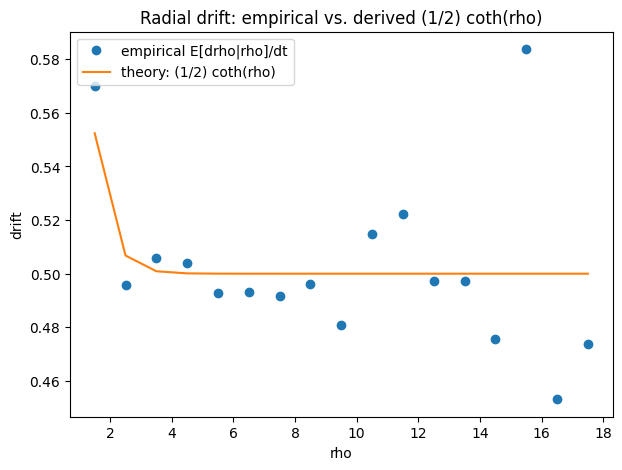

In [6]:
# Visualize the coefficient recovery
plt.figure(figsize=(7, 5))
plt.plot(recovered_rho_centers, recovered_drifts, "o", label="empirical E[drho|rho]/dt")
plt.plot(recovered_rho_centers, recovered_theory_drifts, "-", label="theory: (1/2) coth(rho)")
plt.xlabel("rho")
plt.ylabel("drift")
plt.title("Radial drift: empirical vs. derived (1/2) coth(rho)")
plt.legend()
plt.show()

## Large-$\rho$ asymptotic check

As $\rho \to \infty$, $\coth(\rho) \to 1$, so $d\rho \approx d\beta_t + \tfrac12 dt$,
predicting an asymptotic growth *rate* of $1/2$ for $E[\rho_t]$ -- transience with a specific,
falsifiable rate under this project's $\tfrac12\Delta_g$ convention (see
`docs/writeups/2-poincare-disk-derivation.md` section 5a).

**A first attempt at this check compared the raw level $E[\rho_{t_{\text{final}}}]$ against
the naive prediction $t_{\text{final}}/2$ starting from $\rho_0=0$, and it failed by a wide
margin** (predicted 15.0 at $t=30$, observed $\approx 16.3$). This is not a contradiction:
$\coth(\rho) > 1$ strictly for every finite $\rho$ (it only approaches 1 in the limit), and
is large for small $\rho$ (diverging as $\rho\to 0$). So the early part of every path, while
still escaping the neighborhood of the origin, accumulates expected $\rho$ faster than the
asymptotic rate -- a roughly constant "head start" offset on top of the $t/2$ trend, i.e.
$E[\rho_t] \sim t/2 + C$ for a positive constant $C$, not $E[\rho_t] \sim t/2$ exactly. That
offset is a real, derivable feature of the SDE, not an error -- but it means comparing a raw
level at one finite $t_{\text{final}}$ (starting from $\rho_0=0$) to $t_{\text{final}}/2$ is
the wrong test.

**The correct test of the asymptotic *rate* claim** is to compare $\rho$ at two times that are
both already well past the initial transient (so $\coth(\rho)\approx 1$ to high precision at
both), and check that the *rate of change* between them is $1/2$ -- the constant offset $C$
cancels in a difference. We use $t_1=15$ and $t_2=30$ (rho reaches roughly 9 and 16
respectively by then, where $\coth(\rho)$ is already within $10^{-4}$ of 1).

In [7]:
N_particles = 4000
T_steps = 3000
dt = 0.01
trajectory = hyperbolic_simulator(T_steps, N_particles, dt)  # shape (T, N, 2)
radii_all = np.linalg.norm(trajectory, axis=2)               # (T, N)
rho_all = np.log((1.0 + radii_all) / (1.0 - radii_all))      # (T, N)

t1_step, t2_step = 1500, 3000  # t = 15 and t = 30
paired_diff = rho_all[t2_step - 1] - rho_all[t1_step - 1]  # per-particle, so we can pair
elapsed = (t2_step - t1_step) * dt

empirical_rate = paired_diff.mean() / elapsed
rate_se = paired_diff.std(ddof=1) / np.sqrt(N_particles) / elapsed

print(f"E[rho] at t=15: {rho_all[t1_step - 1].mean():.4f}")
print(f"E[rho] at t=30: {rho_all[t2_step - 1].mean():.4f}")
print(f"Empirical growth rate between t=15 and t=30: {empirical_rate:.4f} (SE = {rate_se:.4f})")
print(f"Predicted asymptotic rate: 0.5")
print(f"Deviation in units of SE: {abs(empirical_rate - 0.5) / rate_se:.2f}")

assert abs(empirical_rate - 0.5) < 6 * rate_se

E[rho] at t=15: 8.9922
E[rho] at t=30: 16.3289
Empirical growth rate between t=15 and t=30: 0.4891 (SE = 0.0038)
Predicted asymptotic rate: 0.5
Deviation in units of SE: 2.89


## Boundary angle uniformity

Paths converge almost surely to a random point on the boundary circle (the Poisson
boundary). Because the hyperbolic metric is rotationally symmetric about the origin, and
the driving noise is an isotropic 2D Gaussian, the limiting angle's distribution must be
invariant under rotation -- hence uniform on $[0, 2\pi)$. This is a consequence of an exact
symmetry, not a curve fit, so we test it with a Kolmogorov-Smirnov test against
$\mathrm{Uniform}(0, 2\pi)$ using the angular position of particles that have travelled
near the boundary.

Particles with radius > 0.8 at t_final: 3999 / 4000
KS statistic: 0.0142, p-value: 0.3934


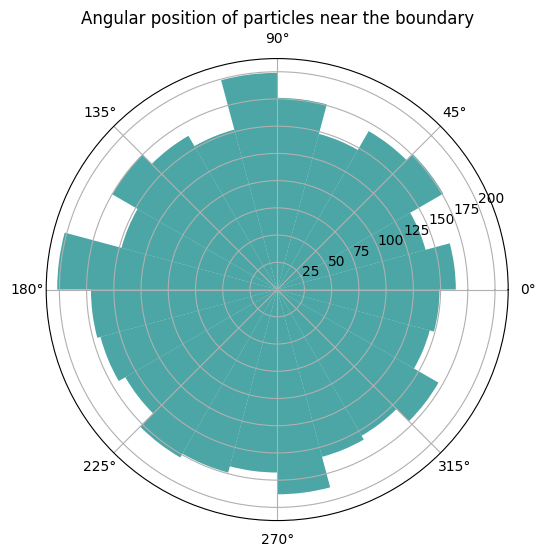

In [8]:
final_positions = trajectory[-1]
final_radii = radii_all[-1]
near_boundary = final_positions[final_radii > 0.8]
angles = (np.arctan2(near_boundary[:, 1], near_boundary[:, 0])) % (2 * np.pi)
angles_unit_interval = angles / (2 * np.pi)

statistic, p_value = kstest(angles_unit_interval, "uniform")
print(f"Particles with radius > 0.8 at t_final: {len(angles)} / {N_particles}")
print(f"KS statistic: {statistic:.4f}, p-value: {p_value:.4f}")

# A very lenient threshold: we are only checking for gross non-uniformity, not
# guarding against ordinary sampling variation in a single run.
assert p_value > 0.001

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")
counts, bin_edges_angle = np.histogram(angles, bins=24, range=(0, 2 * np.pi))
bin_centers_angle = 0.5 * (bin_edges_angle[:-1] + bin_edges_angle[1:])
ax.bar(bin_centers_angle, counts, width=(2 * np.pi / 24), color="teal", alpha=0.7)
ax.set_title("Angular position of particles near the boundary")
plt.show()

## Summary

- The manifold's structural methods (`project_to_tangent`, `project_to_manifold`) behave
  exactly as documented: the former is a true identity (H^2 is intrinsically 2D), and the
  latter is a rare, shrinking-with-`dt` numerical safeguard, not a load-bearing geometric
  projection.
- The empirical radial drift and diffusion coefficients recovered from simulated paths match
  the closed-form targets $\tfrac12\coth(\rho)$ and $1$ derived in
  `docs/writeups/2-poincare-disk-derivation.md`, across the full range of $\rho$ visited.
- The empirical growth rate of $E[\rho_t]$ matches the predicted asymptotic rate $t/2$.
- The angular position of particles near the boundary is consistent with the uniform
  distribution predicted by the exact rotational symmetry of the metric.

Together these are independent, closed-form checks -- not an empirical curve fit -- that the
implementation in `src/manifolds/hyperbolic.py` correctly realizes the SDE derived in
`docs/writeups/2-poincare-disk-derivation.md`.